# Water Potability and Safety Risk Analyzer — Exploration & Modeling

This notebook walks through the full workflow:
1. Load and inspect the dataset
2. Clean missing values
3. Exploratory Data Analysis (EDA)
4. Feature engineering / scaling
5. Train classification models
6. Evaluate models
7. Feature importance
8. Parameter-level safety flagging + risk scoring demo


In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import load_raw_data, missing_value_report, clean_data, train_test_split_data
from reference_ranges import FEATURE_COLUMNS, TARGET_COLUMN, SAFE_RANGES
from utils import flag_parameters, risk_score_from_flags, build_recommendation

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Load Data

In [2]:
raw_df = load_raw_data("../data/water_potability.csv")
print(raw_df.shape)
raw_df.head()

(3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## 2. Inspect Missing Values

In [3]:
missing_value_report(raw_df)

,missing_count,missing_pct
Sulfate,781,23.84
ph,491,14.99
Trihalomethanes,162,4.95


## 3. Clean Data
We impute missing values using the median computed **within each Potability class**,
since safe and unsafe water samples tend to have different typical parameter values.

In [4]:
clean_df = clean_data(raw_df, strategy="median_by_class")
print(clean_df.shape, "| remaining NaNs:", clean_df.isnull().sum().sum())
clean_df.head()

(3276, 10) | remaining NaNs: 0


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.035456,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.389426,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.389426,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## 4. Exploratory Data Analysis

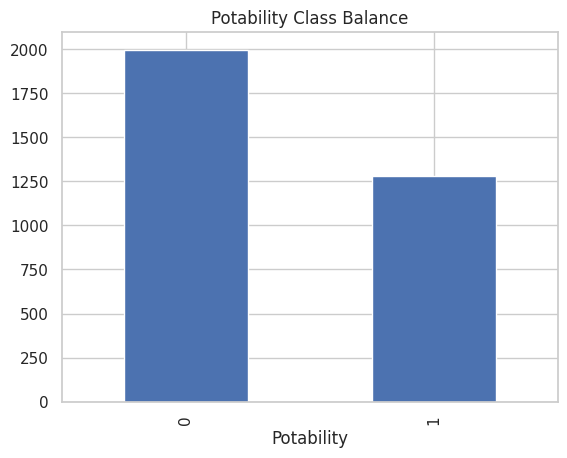

In [5]:
clean_df[TARGET_COLUMN].value_counts().plot(kind="bar", title="Potability Class Balance")
plt.show()

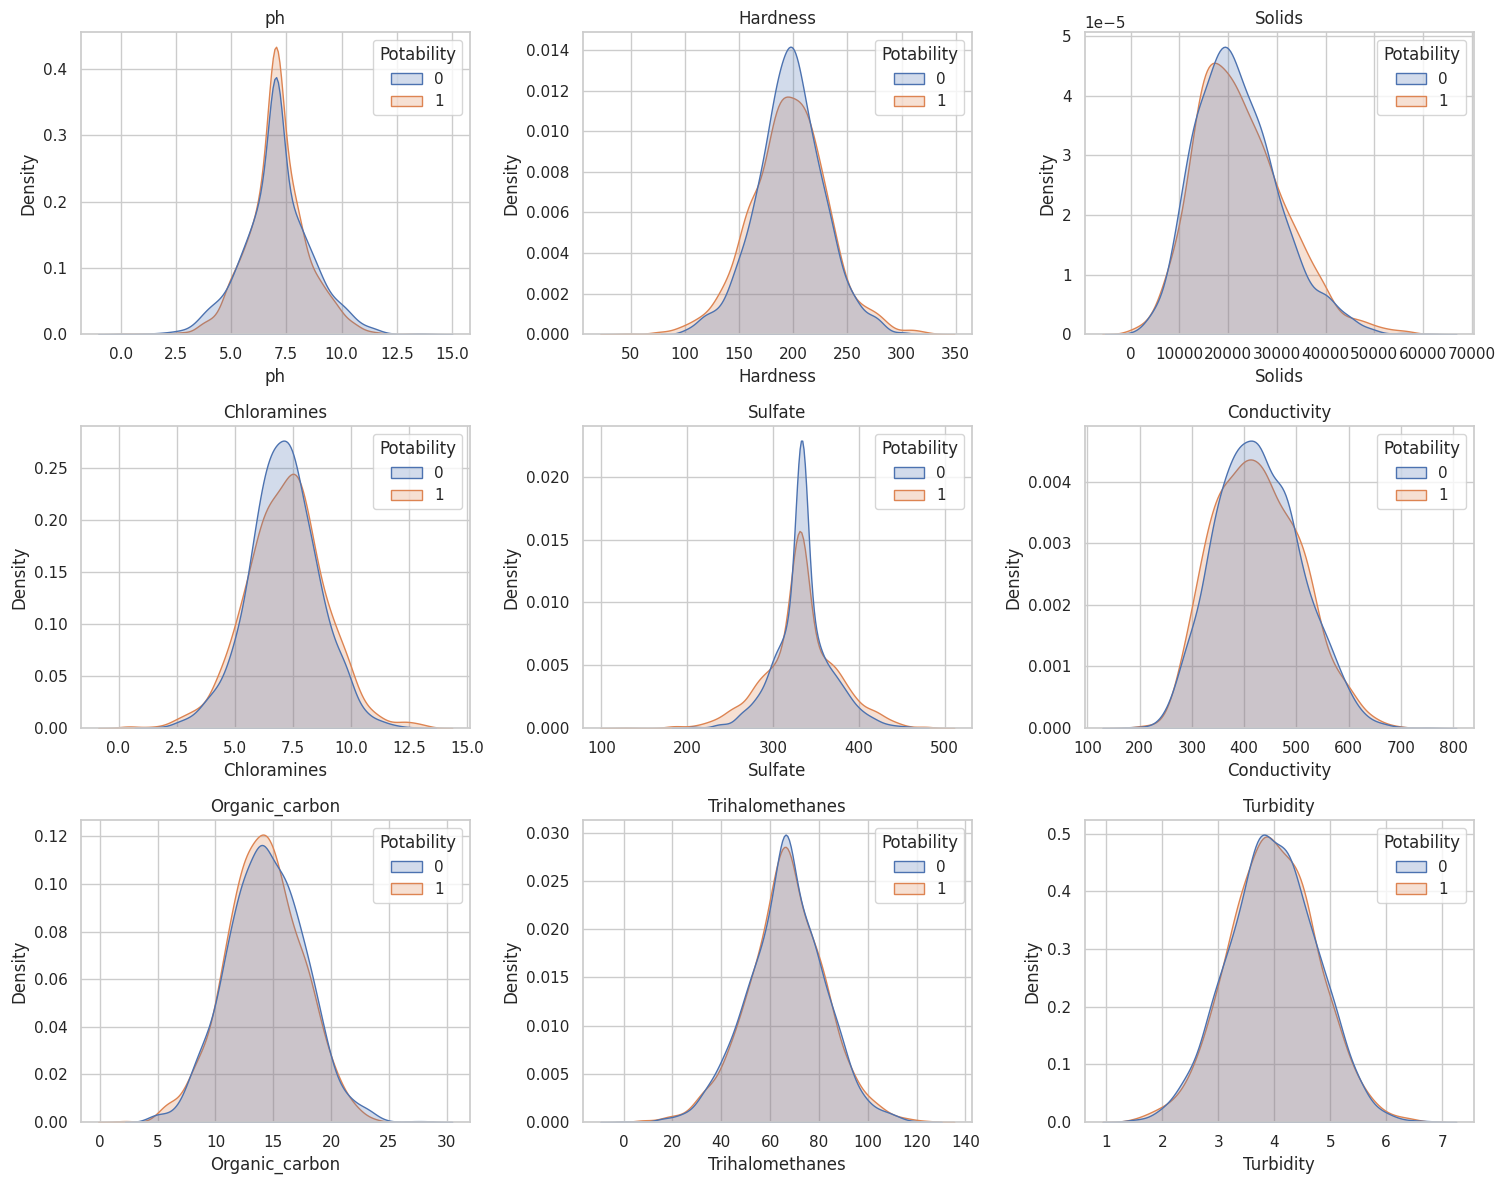

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), FEATURE_COLUMNS):
    sns.kdeplot(data=clean_df, x=col, hue=TARGET_COLUMN, fill=True, ax=ax, common_norm=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

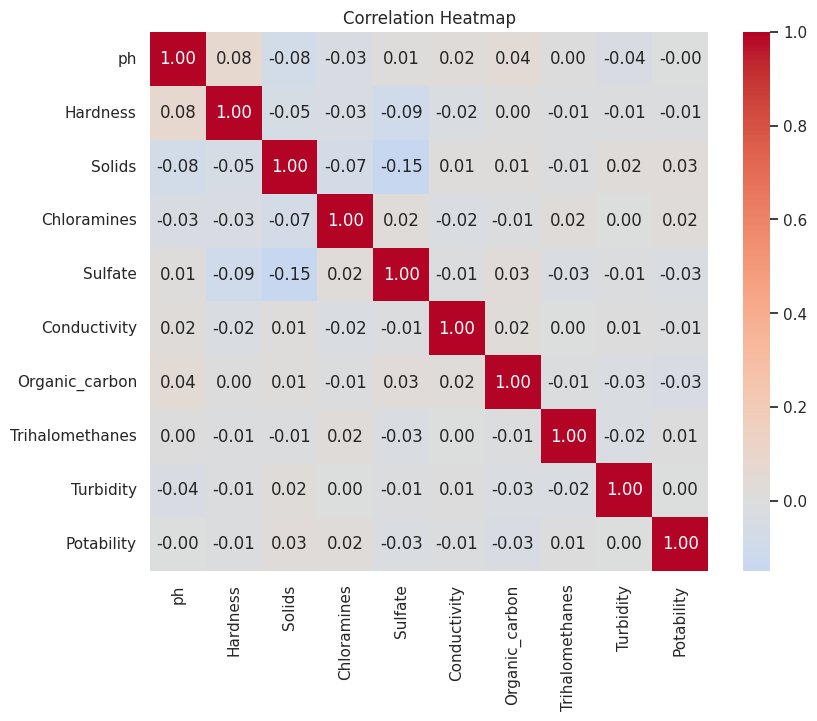

In [7]:
plt.figure(figsize=(9,7))
corr = clean_df[FEATURE_COLUMNS + [TARGET_COLUMN]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## 5. Train / Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split_data(clean_df)
X_train.shape, X_test.shape

((2620, 9), (656, 9))

## 6. Train Models

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

tree = DecisionTreeClassifier(max_depth=8, random_state=42)
tree.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)

print("Models trained.")

Models trained.


## 7. Evaluate Models

In [10]:
for name, model, X_te in [
    ("Logistic Regression", log_reg, X_test_scaled),
    ("Decision Tree", tree, X_test),
    ("Random Forest", rf, X_test),
]:
    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1]
    print(f"--- {name} ---")
    print(classification_report(y_test, preds, target_names=["Not Potable", "Potable"]))
    print("ROC-AUC:", round(roc_auc_score(y_test, probs), 3))
    print("Confusion matrix:\n", confusion_matrix(y_test, preds))
    print()

--- Logistic Regression ---
              precision    recall  f1-score   support

 Not Potable       0.61      1.00      0.76       400
     Potable       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656

ROC-AUC: 0.554
Confusion matrix:
 [[400   0]
 [256   0]]

--- Decision Tree ---
              precision    recall  f1-score   support

 Not Potable       0.76      0.88      0.81       400
     Potable       0.75      0.57      0.65       256

    accuracy                           0.76       656
   macro avg       0.75      0.72      0.73       656
weighted avg       0.76      0.76      0.75       656

ROC-AUC: 0.819
Confusion matrix:
 [[350  50]
 [109 147]]

--- Random Forest ---
              precision    recall  f1-score   support

 Not Potable       0.79      0.91      0.85       400
     Potable       0.82      0.62      0.71      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 8. Feature Importance (Random Forest)

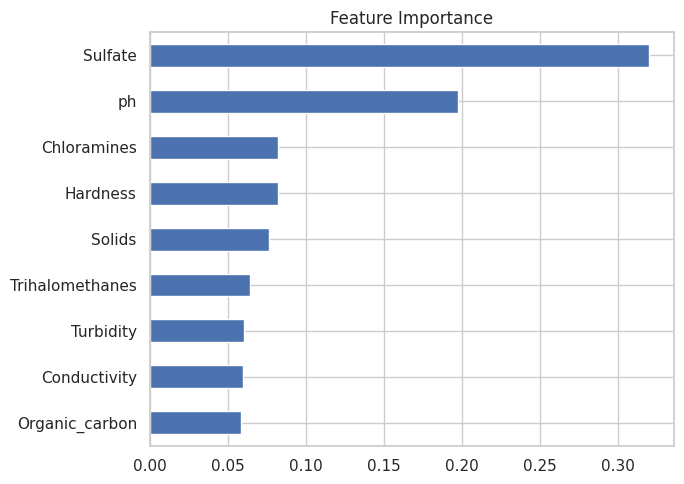

In [11]:
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLUMNS).sort_values()
importances.plot(kind="barh", figsize=(7,5), title="Feature Importance")
plt.tight_layout()
plt.show()

## 9. Safety Risk Analyzer Demo
Combine the trained model with rule-based parameter flags.

In [12]:
sample = clean_df.sample(1, random_state=3).iloc[0]
sample_dict = sample[FEATURE_COLUMNS].to_dict()

pred = int(rf.predict(pd.DataFrame([sample_dict]))[0])
flags = flag_parameters(sample_dict)
risk_info = risk_score_from_flags(flags)
recommendation = build_recommendation(pred, risk_info, flags)

print("Actual Potability:", sample[TARGET_COLUMN])
print("Predicted:", "Potable" if pred == 1 else "Not Potable")
print("Risk info:", risk_info)
print("Recommendation:", recommendation)
pd.DataFrame(flags)

Actual Potability: 1.0
Predicted: Potable
Risk info: {'unsafe_parameter_count': 5, 'total_parameters_checked': 9, 'risk_score': 55.6, 'risk_band': 'High Risk'}
Recommendation: The model predicts this sample is POTABLE overall, but ph, Solids, Chloramines, Sulfate, Organic_carbon fall outside recommended safe ranges. Consider verifying with a lab test before use.


,parameter,value,safe_range,unit,status,note
0,ph,6.382,"(6.5, 8.5)",,Unsafe,Acceptable pH range for drinking water
1,Hardness,212.839,"(0, 300)",mg/L,Safe,Soft-to-moderately-hard water is preferred
2,Solids,24259.752,"(0, 500)",ppm,Unsafe,"Total Dissolved Solids (TDS), WHO desirable limit"
3,Chloramines,7.361,"(0, 4)",ppm,Unsafe,Max allowed disinfectant residual
4,Sulfate,331.838,"(0, 250)",mg/L,Unsafe,Upper limit before taste/health issues
5,Conductivity,342.581,"(0, 400)",μS/cm,Safe,Typical acceptable conductivity
6,Organic_carbon,12.333,"(0, 2)",ppm,Unsafe,US EPA guidance for treated water (TOC)
7,Trihalomethanes,67.749,"(0, 80)",μg/L,Safe,US EPA maximum contaminant level
8,Turbidity,2.881,"(0, 5)",NTU,Safe,WHO recommended maximum turbidity
